# Gas Disk Profile and Migration Example

This notebook demonstrates the Python-side validation interface for a modified GENGA gas-disk prescription. The corresponding CUDA source file is provided as `examples/dataset/gas_config/gas.cu`, which can be used to replace the original GENGA gas-disk configuration file. The Python module `accrediff.gas_migration` reproduces the same disk structure and torque prescription in a lightweight form, allowing the user to inspect surface-density profiles, torque components, torque zero-crossings, and migration tracks before or after running GENGA.


---
## 1. Setup

The gas-disk utilities use GENGA-like code units internally (`G=1`, `Mstar=1`, `AU=1`). User-facing parameters in this notebook are given in common physical units where appropriate, such as particle mass in Earth masses and surface density in g cm$^{-2}$. The goal of this notebook is validation and inspection of the modified gas prescription, not execution of the CUDA `gas.cu` file itself.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = None
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "accrediff").exists():
        PROJECT_ROOT = parent
        sys.path.insert(0, str(parent / "src"))
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the AccreDiff repository root.")

import accrediff as ad

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)


---
## 2. Build a Gas-Disk Model

`Gas_ModelConfig` stores the disk, particle, and integration parameters used by the Python-side validation model. `Gas_build_model` returns the disk model, torque model, unit converter, and migration integrator in one dictionary. These settings mirror the modified gas-disk prescription implemented in the bundled `gas.cu` example file.


In [2]:
cfg = ad.Gas_ModelConfig(
    particle_mass_mearth=0.1,  # migrating particle mass, in Earth masses
    a0=0.5,                    # initial semi-major axis, in AU
    tau_decay_myr=1.0,         # exponential gas decay timescale, in Myr
    a_alpha1=1.0,
    a_alpha2=0.5,
    Sigma0_cgs=1700.0,         # gas surface density normalization, g cm^-2
    alpha_visc=1.0e-4,
    prandtl=1.0,
    use_saturation=True,
    t_max_myr=5.0,
    n_steps=4000,
)

model = ad.Gas_build_model(cfg)
units = model["units"]
disk = model["disk"]
torque = model["torque"]
integrator = model["integrator"]

r_grid = np.linspace(0.1, 4.0, 800)
profile_t0 = torque.profile(r_grid, t_code=0.0)

print(f"Particle mass : {cfg.particle_mass_mearth:.2f} M_earth")
print(f"Initial a     : {cfg.a0:.2f} AU")
print(f"Gas decay tau : {cfg.tau_decay_myr:.2f} Myr")
print(f"Sigma0        : {cfg.Sigma0_cgs:.0f} g cm^-2")


Particle mass : 0.10 M_earth
Initial a     : 0.50 AU
Gas decay tau : 1.00 Myr
Sigma0        : 1700 g cm^-2


---
## 3. Gas Surface-Density Evolution

The disk model evaluates the surface density as a radial profile with exponential time decay. The helper `sigma_cgs` returns the profile in g cm$^{-2}$.


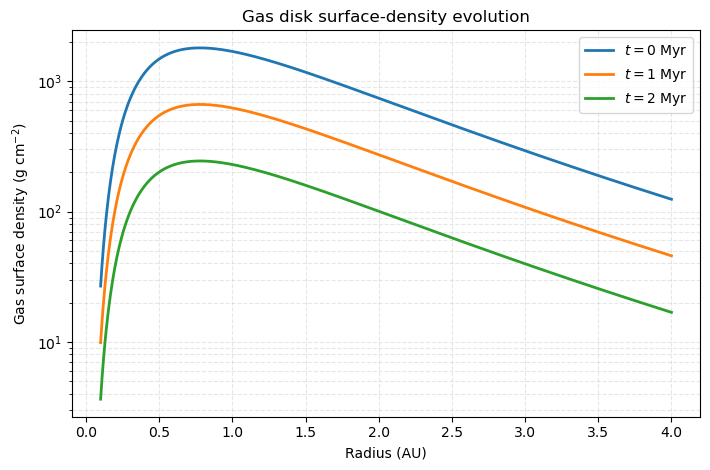

In [3]:
time_snapshots = [0.0, 1.0, 2.0]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for t_myr, color in zip(time_snapshots, colors):
    t_code = units.myr_to_code(t_myr)
    sigma_cgs = disk.sigma_cgs(r_grid, t_code=t_code)
    ax.plot(r_grid, sigma_cgs, color=color, lw=2, label=fr"$t={t_myr:.0f}$ Myr")

ax.set_yscale("log")
ax.set_xlabel("Radius (AU)")
ax.set_ylabel(r"Gas surface density (g cm$^{-2}$)")
ax.set_title("Gas disk surface-density evolution")
ax.grid(True, which="both", alpha=0.3, ls="--")
ax.legend(frameon=True)
fig.tight_layout()
plt.show()


---
## 4. Static Torque Profile

The torque model combines Lindblad, barotropic corotation, and entropy-related corotation terms following the Paardekooper et al. style prescription implemented in `Gas_TorqueModel`. Torque zero-crossings mark locations where the sign of migration changes.


Torque zero crossing: 0.9167 AU


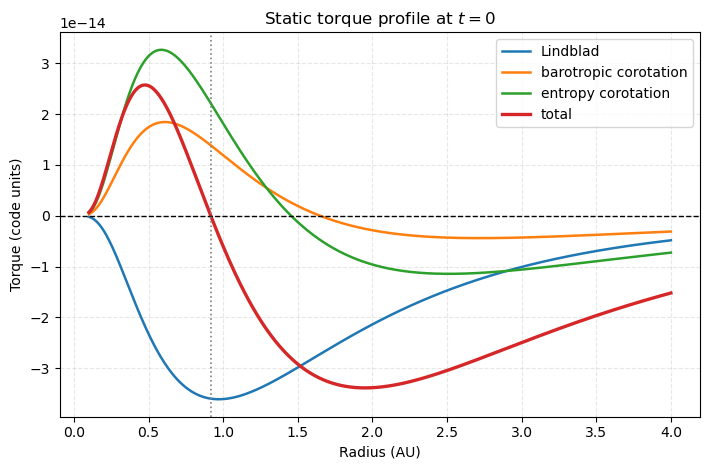

In [4]:
def find_zero_crossings(x, y):
    """Return linearly interpolated zero-crossing positions."""
    sign_changes = np.where(np.diff(np.sign(y)) != 0)[0]
    roots = []
    for idx in sign_changes:
        x0, x1 = x[idx], x[idx + 1]
        y0, y1 = y[idx], y[idx + 1]
        roots.append(x0 - y0 * (x1 - x0) / (y1 - y0))
    return roots

zero_crossings = find_zero_crossings(profile_t0["r"], profile_t0["gamma_tot"])
for root in zero_crossings:
    print(f"Torque zero crossing: {root:.4f} AU")

components = [
    ("gamma_l", "Lindblad", "#1f77b4", 1.8),
    ("gamma_c_baro", "barotropic corotation", "#ff7f0e", 1.8),
    ("gamma_c_ent", "entropy corotation", "#2ca02c", 1.8),
    ("gamma_tot", "total", "#d62728", 2.4),
]

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for key, label, color, lw in components:
    ax.plot(profile_t0["r"], profile_t0[key], label=label, color=color, lw=lw)

ax.axhline(0.0, color="black", ls="--", lw=1)
for root in zero_crossings:
    ax.axvline(root, color="gray", ls=":", lw=1.2)

ax.set_xlabel("Radius (AU)")
ax.set_ylabel("Torque (code units)")
ax.set_title(r"Static torque profile at $t=0$")
ax.grid(alpha=0.3, ls="--")
ax.legend(frameon=True)
fig.tight_layout()
plt.show()


---
## 5. Migration Track: Model vs. Bundled Simulation Output

The bundled `examples/dataset/gas_config/One_*.csv` files provide GENGA-style test outputs generated with the modified gas-disk setup. Here we compare those tracks with the analytic migration integrator using the same initial semi-major axes. Simulation outputs are shown as dashed lines with hollow circular markers, while the Python-side model is shown as solid lines.


In [5]:
def run_migration_track(a0):
    """Build a model with a selected initial semi-major axis and integrate a(t)."""
    cfg_i = ad.Gas_ModelConfig(
        particle_mass_mearth=0.1,
        a0=a0,
        tau_decay_myr=1.0,
        a_alpha1=1.0,
        a_alpha2=0.5,
        Sigma0_cgs=1700.0,
        alpha_visc=1.0e-4,
        prandtl=1.0,
        use_saturation=True,
        t_max_myr=5.0,
        n_steps=4000,
    )
    return ad.Gas_build_model(cfg_i)["integrator"].integrate_full()

initial_a = [0.5, 1.0, 1.5]
theory_tracks = {a0: run_migration_track(a0) for a0 in initial_a}

simulation_dir = PROJECT_ROOT / "examples" / "dataset" / "gas_config"
simulation_files = {
    0.5: simulation_dir / "One_01.csv",
    1.0: simulation_dir / "One_02.csv",
    1.5: simulation_dir / "One_03.csv",
}
simulation_tracks = {a0: pd.read_csv(path) for a0, path in simulation_files.items()}

summary = []
for a0 in initial_a:
    theory = theory_tracks[a0]
    sim = simulation_tracks[a0]
    summary.append({
        "a0_AU": a0,
        "theory_final_a_AU": theory["a"][-1],
        "simulation_final_a_AU": sim["a_1"].iloc[-1],
        "final_difference_AU": theory["a"][-1] - sim["a_1"].iloc[-1],
    })

pd.DataFrame(summary)


,a0_AU,theory_final_a_AU,simulation_final_a_AU,final_difference_AU
0,0.5,0.8887,0.8887,7.7509e-05
1,1.0,0.9208,0.9210,-1.6263e-04
2,1.5,0.9476,0.9477,-5.8226e-05


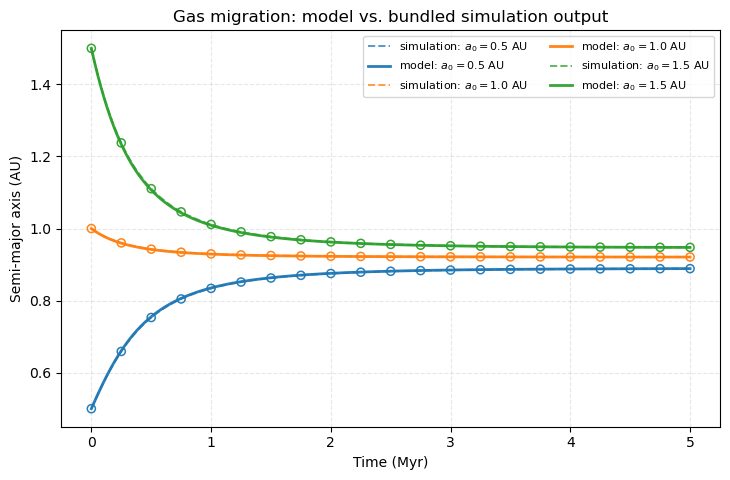

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.9))
colors = {0.5: "C0", 1.0: "C1", 1.5: "C2"}
marker_step = 25

for a0 in initial_a:
    sim = simulation_tracks[a0]
    theory = theory_tracks[a0]
    color = colors[a0]

    # Simulation output: dashed line plus hollow circular markers.
    ax.plot(
        sim["Time"], sim["a_1"],
        color=color, lw=1.4, ls="--", alpha=0.75,
        label=fr"simulation: $a_0={a0:.1f}$ AU",
    )
    ax.scatter(
        sim["Time"].iloc[::marker_step], sim["a_1"].iloc[::marker_step],
        s=34, facecolors="none", edgecolors=color, linewidths=1.1,
        alpha=0.95, zorder=3,
    )

    # Gas-migration module output: solid line.
    ax.plot(
        theory["t_myr"], theory["a"],
        color=color, lw=2.0, alpha=0.95,
        label=fr"model: $a_0={a0:.1f}$ AU",
    )

ax.set_xlabel("Time (Myr)")
ax.set_ylabel("Semi-major axis (AU)")
ax.set_title("Gas migration: model vs. bundled simulation output")
ax.grid(alpha=0.3, ls="--")
ax.legend(frameon=True, fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


---
## 6. Workflow Note

This notebook demonstrates the Python-side profile, torque, and migration validation utilities only. It does not compile or rerun GENGA. In an extended workflow, the bundled `gas.cu` file can be used to replace the corresponding GENGA gas-disk configuration source, while this notebook can be used to inspect the prescription and compare analytic migration tracks with GENGA outputs.
